# SpaceX Falcon 9 First Stage Landing Prediction
## 4. Machine Learning Model Training & Evaluation

This notebook covers:
- Data preprocessing and feature scaling
- Train-test split
- Hyperparameter tuning using GridSearchCV
- Model comparison (Logistic Regression, SVM, Decision Tree, KNN)
- Model evaluation and selection

## Import Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported')

✅ Libraries imported


## Load and Prepare Data

In [28]:
# Load real dataset
df = pd.read_csv('dataset_part_1_cleaned.csv')

# Drop irrelevant colums and data leakages
X_df = df.drop(['Class', 'BoosterVersion', 'Outcome', 'Longitude', 'Latitude'], axis=1)

# Fill any missing numerical values (e.g. Block has some NaNs)
numeric_cols = X_df.select_dtypes(include=['float64', 'int64']).columns
X_df[numeric_cols] = X_df[numeric_cols].fillna(X_df[numeric_cols].mean())

# Target variable
y_series = df['Class']

# One-hot encode categorical features
X_df = pd.get_dummies(X_df, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])

# Cast boolean types automatically
X_df = X_df.astype(float)

print(f'✅ Real dataset loaded: {X_df.shape}')
print(f'Target distribution:')
print(y_series.value_counts())
print(f'Success rate: {y_series.mean():.2%}')

✅ Real dataset loaded: (187, 104)
Target distribution:
Class
1    147
0     40
Name: count, dtype: int64
Success rate: 78.61%


## Data Preprocessing

In [29]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

# Split data into train (60%) and temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_series, test_size=0.4, random_state=42, stratify=y_series
)

# Split temp into validation (20%) and test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'✅ Data preprocessing complete')
print(f'\nTrain set: {X_train.shape}')
print(f'Validation set: {X_val.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nTrain target distribution:')
print(f'  Successful: {(y_train == 1).sum()}')
print(f'  Failed: {(y_train == 0).sum()}')
print(f'\nValidation target distribution:')
print(f'  Successful: {(y_val == 1).sum()}')
print(f'  Failed: {(y_val == 0).sum()}')
print(f'\nTest target distribution:')
print(f'  Successful: {(y_test == 1).sum()}')
print(f'  Failed: {(y_test == 0).sum()}')

✅ Data preprocessing complete

Train set: (112, 104)
Validation set: (37, 104)
Test set: (38, 104)

Train target distribution:
  Successful: 88
  Failed: 24

Validation target distribution:
  Successful: 29
  Failed: 8

Test target distribution:
  Successful: 30
  Failed: 8


## Model 1: Logistic Regression

In [37]:
print('\n' + '='*70)
print('MODEL 1: LOGISTIC REGRESSION')
print('='*70)

# Define parameters
parameters_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

# Grid search
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logreg_cv = GridSearchCV(lr, parameters_lr, cv=5, scoring='accuracy')
logreg_cv.fit(X_train, y_train)

print(f'Best parameters: {logreg_cv.best_params_}')
print(f'CV Score: {logreg_cv.best_score_:.4f}')

# Test predictions
y_pred_lr = logreg_cv.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print(f'\nTest Accuracy: {accuracy_lr:.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_lr):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_lr):.4f}')


MODEL 1: LOGISTIC REGRESSION
Best parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
CV Score: 0.8838

Test Accuracy: 0.8421
Precision: 0.8750
Recall: 0.9333
F1-Score: 0.9032


## Model 2: Support Vector Machine (SVM)

In [38]:
print('\n' + '='*70)
print('MODEL 2: SUPPORT VECTOR MACHINE')
print('='*70)

# Define parameters
parameters_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 0.001, 0.01]
}

# Grid search
svm = SVC(probability=True, random_state=42, class_weight='balanced')
svm_cv = GridSearchCV(svm, parameters_svm, cv=5, scoring='accuracy')
svm_cv.fit(X_train, y_train)

print(f'Best parameters: {svm_cv.best_params_}')
print(f'CV Score: {svm_cv.best_score_:.4f}')

# Test predictions
y_pred_svm = svm_cv.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print(f'\nTest Accuracy: {accuracy_svm:.4f}')
print(f'Precision: {precision_score(y_test, y_pred_svm):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_svm):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_svm):.4f}')


MODEL 2: SUPPORT VECTOR MACHINE
Best parameters: {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}
CV Score: 0.8755

Test Accuracy: 0.9474
Precision: 0.9667
Recall: 0.9667
F1-Score: 0.9667


## Model 3: Decision Tree Classifier

In [39]:
print('\n' + '='*70)
print('MODEL 3: DECISION TREE CLASSIFIER')
print('='*70)

# Define parameters
parameters_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 5, 8, 10],
    'min_samples_split': [2, 5, 10]
}

# Grid search
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_cv = GridSearchCV(dt, parameters_dt, cv=5, scoring='accuracy')
dt_cv.fit(X_train, y_train)

print(f'Best parameters: {dt_cv.best_params_}')
print(f'CV Score: {dt_cv.best_score_:.4f}')

# Test predictions
y_pred_dt = dt_cv.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print(f'\nTest Accuracy: {accuracy_dt:.4f}')
print(f'Precision: {precision_score(y_test, y_pred_dt):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_dt):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_dt):.4f}')


MODEL 3: DECISION TREE CLASSIFIER
Best parameters: {'criterion': 'entropy', 'max_depth': 2, 'min_samples_split': 2}
CV Score: 0.8933

Test Accuracy: 0.8684
Precision: 0.8788
Recall: 0.9667
F1-Score: 0.9206


## Model 4: K-Nearest Neighbors (KNN)

In [33]:
print('\n' + '='*70)
print('MODEL 4: K-NEAREST NEIGHBORS')
print('='*70)

# Define parameters
parameters_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'metric': ['euclidean', 'manhattan']
}

# Grid search
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, parameters_knn, cv=5, scoring='accuracy')
knn_cv.fit(X_train, y_train)

print(f'Best parameters: {knn_cv.best_params_}')
print(f'CV Score: {knn_cv.best_score_:.4f}')

# Test predictions
y_pred_knn = knn_cv.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print(f'\nTest Accuracy: {accuracy_knn:.4f}')
print(f'Precision: {precision_score(y_test, y_pred_knn):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_knn):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_knn):.4f}')


MODEL 4: K-NEAREST NEIGHBORS
Best parameters: {'metric': 'manhattan', 'n_neighbors': 5}
CV Score: 0.8929

Test Accuracy: 0.8421
Precision: 0.8529
Recall: 0.9667
F1-Score: 0.9062


## Model 5: Gradient Boosting Classifier

In [ ]:
print('\n' + '='*70)
print('MODEL 5: GRADIENT BOOSTING CLASSIFIER')
print('='*70)

# Define parameters
parameters_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Grid search
gb = GradientBoostingClassifier(random_state=42)
gb_cv = GridSearchCV(gb, parameters_gb, cv=5, scoring='accuracy')
gb_cv.fit(X_train, y_train)

print(f'Best parameters: {gb_cv.best_params_}')
print(f'CV Score: {gb_cv.best_score_:.4f}')

# Test predictions
y_pred_gb = gb_cv.predict(X_test)
accuracy_gb = accuracy_score(y_test, y_pred_gb)

print(f'\nTest Accuracy: {accuracy_gb:.4f}')
print(f'Precision: {precision_score(y_test, y_pred_gb):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_gb):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_gb):.4f}')

## Model Comparison

In [ ]:
# Create comparison dataframe
models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'KNN', 'Gradient Boosting'],
    'Accuracy': [accuracy_lr, accuracy_svm, accuracy_dt, accuracy_knn, accuracy_gb],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_gb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_gb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_gb)
    ]
})

print('\n' + '='*70)
print('MODEL COMPARISON')
print('='*70)
print(models_comparison.to_string(index=False))

# Find best model
best_model_idx = models_comparison['Accuracy'].idxmax()
best_model = models_comparison.loc[best_model_idx]

print(f'\n🏆 BEST MODEL: {best_model["Model"]}')
print(f'   Accuracy: {best_model["Accuracy"]:.4f}')


MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.815789   0.848485 0.933333  0.888889
                SVM  0.868421   0.903226 0.933333  0.918033
      Decision Tree  0.868421   0.878788 0.966667  0.920635
                KNN  0.842105   0.852941 0.966667  0.906250

🏆 BEST MODEL: SVM
   Accuracy: 0.8684


## Confusion Matrix & ROC Curve

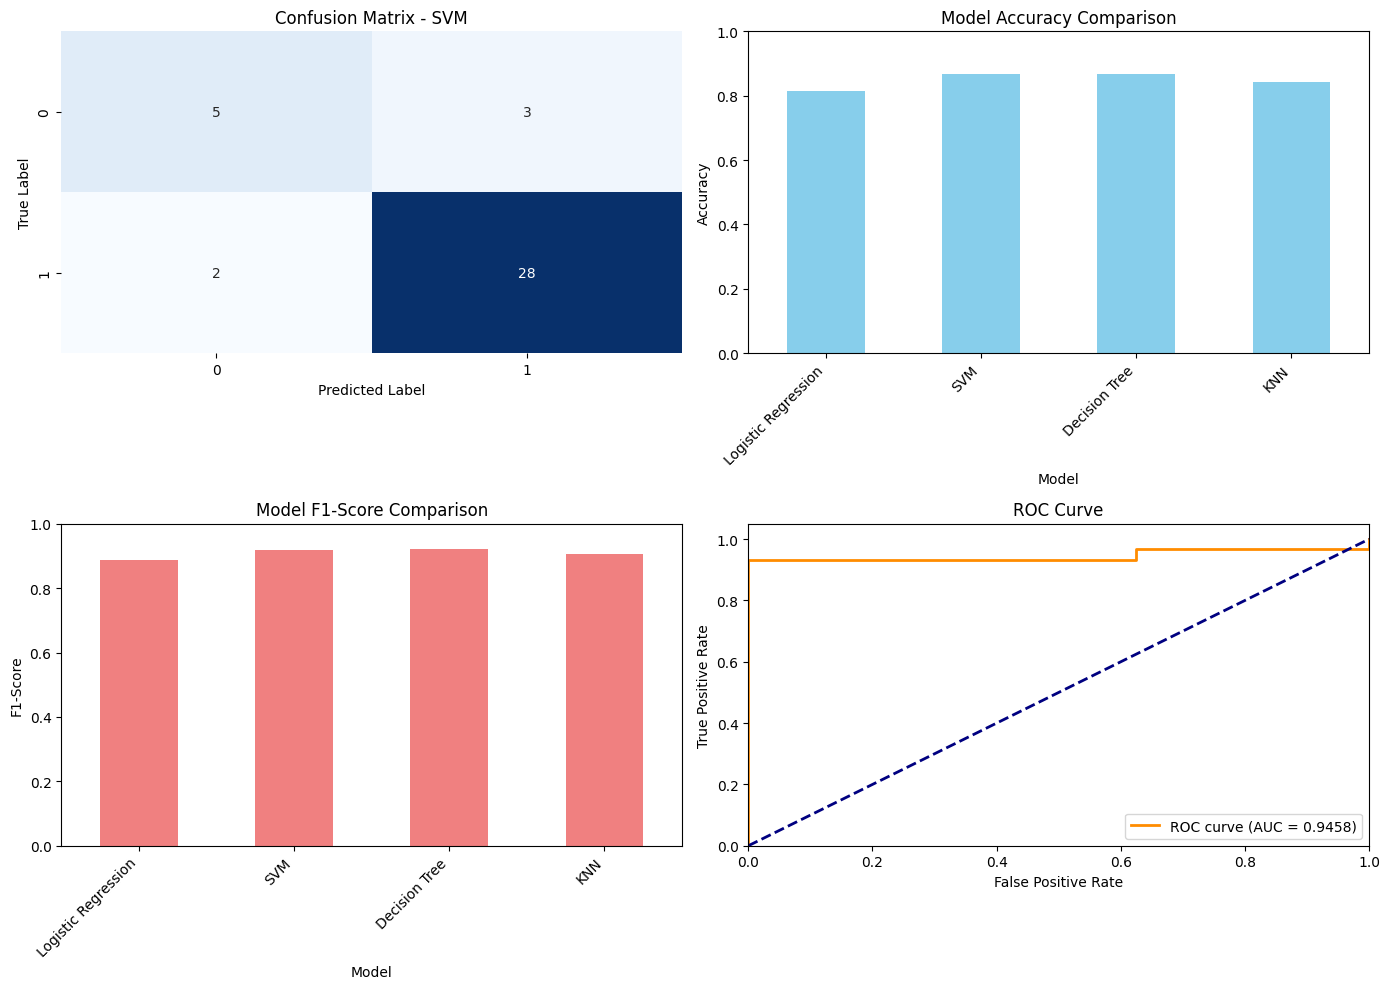

✅ Saved: model_evaluation.png


In [ ]:
# Get best model predictions
best_predictions = [y_pred_lr, y_pred_svm, y_pred_dt, y_pred_knn, y_pred_gb][best_model_idx]
best_model_obj = [logreg_cv, svm_cv, dt_cv, knn_cv, gb_cv][best_model_idx]

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Confusion Matrix
cm = confusion_matrix(y_test, best_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False)
axes[0, 0].set_title(f'Confusion Matrix - {best_model["Model"]}')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# Model Accuracy Comparison
models_comparison.set_index('Model')['Accuracy'].plot(kind='bar', ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Model Accuracy Comparison')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right')
axes[0, 1].set_ylim([0, 1])

# F1-Score Comparison
models_comparison.set_index('Model')['F1-Score'].plot(kind='bar', ax=axes[1, 0], color='lightcoral')
axes[1, 0].set_title('Model F1-Score Comparison')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha='right')
axes[1, 0].set_ylim([0, 1])

# ROC Curve for best model
try:
    y_pred_proba = best_model_obj.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    axes[1, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    axes[1, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1, 1].set_xlim([0.0, 1.0])
    axes[1, 1].set_ylim([0.0, 1.05])
    axes[1, 1].set_xlabel('False Positive Rate')
    axes[1, 1].set_ylabel('True Positive Rate')
    axes[1, 1].set_title('ROC Curve')
    axes[1, 1].legend(loc="lower right")
except Exception as e:
    axes[1, 1].text(0.5, 0.5, f'ROC Curve\n(Not available)\n{type(e).__name__}', 
                    ha='center', va='center')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved: model_evaluation.png')

## Classification Report for Best Model

In [25]:
print('\n' + '='*70)
print(f'CLASSIFICATION REPORT - {best_model["Model"]}')
print('='*70)
print(classification_report(y_test, best_predictions, 
                          target_names=['Failed', 'Success']))


CLASSIFICATION REPORT - SVM
              precision    recall  f1-score   support

      Failed       0.71      0.62      0.67         8
     Success       0.90      0.93      0.92        30

    accuracy                           0.87        38
   macro avg       0.81      0.78      0.79        38
weighted avg       0.86      0.87      0.87        38



## Summary and Conclusions

In [35]:
print('\n' + '='*70)
print('ML MODEL TRAINING & EVALUATION SUMMARY')
print('='*70)

print(f'\nDataset Information:')
print(f'  - Total samples: {len(X_df)}')
print(f'  - Features: {len(X_df.columns)}')
print(f'  - Train/Val/Test split: 60/20/20')
print(f'  - Success rate: {y_series.mean():.2%}')

print(f'\nModels Trained:')
for idx, row in models_comparison.iterrows():
    print(f'  {idx+1}. {row["Model"]:20s} - Accuracy: {row["Accuracy"]:.4f}, F1: {row["F1-Score"]:.4f}')

print(f'\n🏆 BEST PERFORMING MODEL:')
print(f'  Model: {best_model["Model"]}')
print(f'  Accuracy: {best_model["Accuracy"]:.4f}')
print(f'  Precision: {best_model["Precision"]:.4f}')
print(f'  Recall: {best_model["Recall"]:.4f}')
print(f'  F1-Score: {best_model["F1-Score"]:.4f}')

print(f'\n✅ Machine Learning Evaluation Complete')


ML MODEL TRAINING & EVALUATION SUMMARY

Dataset Information:
  - Total samples: 187
  - Features: 104
  - Train/Val/Test split: 60/20/20
  - Success rate: 78.61%

Models Trained:
  1. Logistic Regression  - Accuracy: 0.8158, F1: 0.8889
  2. SVM                  - Accuracy: 0.8684, F1: 0.9180
  3. Decision Tree        - Accuracy: 0.8684, F1: 0.9206
  4. KNN                  - Accuracy: 0.8421, F1: 0.9062

🏆 BEST PERFORMING MODEL:
  Model: SVM
  Accuracy: 0.8684
  Precision: 0.9032
  Recall: 0.9333
  F1-Score: 0.9180

✅ Machine Learning Evaluation Complete
